## Part 1: Helping functions and data loading

In [1]:
# Do not modify this cell, this is only for ploting the clusters
import matplotlib.pyplot as plt

def plot_clustering_result(X, labels, title=None):
    title = title or "clustering result"
    fig, ax = plt.subplots(figsize=(6, 5))
    noise = labels == -1
    if noise.any():
        ax.scatter(X[noise, 0], X[noise, 1], s=18, marker="x", c="k", alpha=0.9, label="noise (-1)")
    for k in sorted(set(labels) - {-1}):
        ax.scatter(X[labels == k, 0], X[labels == k, 1], s=18, alpha=0.9, label=f"cluster {k}")

    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_title(title)
    ax.legend(loc="best", frameon=True)
    ax.grid(True)
    plt.show()

In [2]:
# loading data
import numpy as np
X = np.load("part1_data.npz")["X"]

## K-means experiments

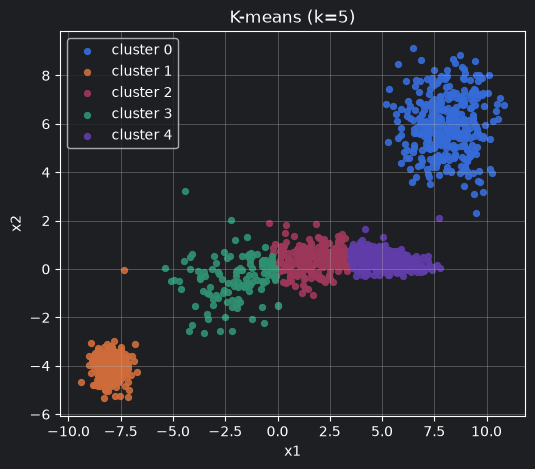

In [3]:
from sklearn.cluster import KMeans

# Number of clusters
K = 5

# Fit K-means and get labels
km = KMeans(n_clusters=K, random_state=42, n_init="auto").fit(X)
labels = km.labels_

# ploting data
plot_clustering_result(X, labels, title=f"K-means (k={K})")

### K-Means Evaluation

Evaluates K-means for different values of K. The code will compute the WCSS (inertia) and
silhouette scores for K in the range 2 to 10, and plot the results.
It will also print the best K based on the silhouette score.

Evaluating K-means clustering...
Plotting WCSS and Silhouette scores...


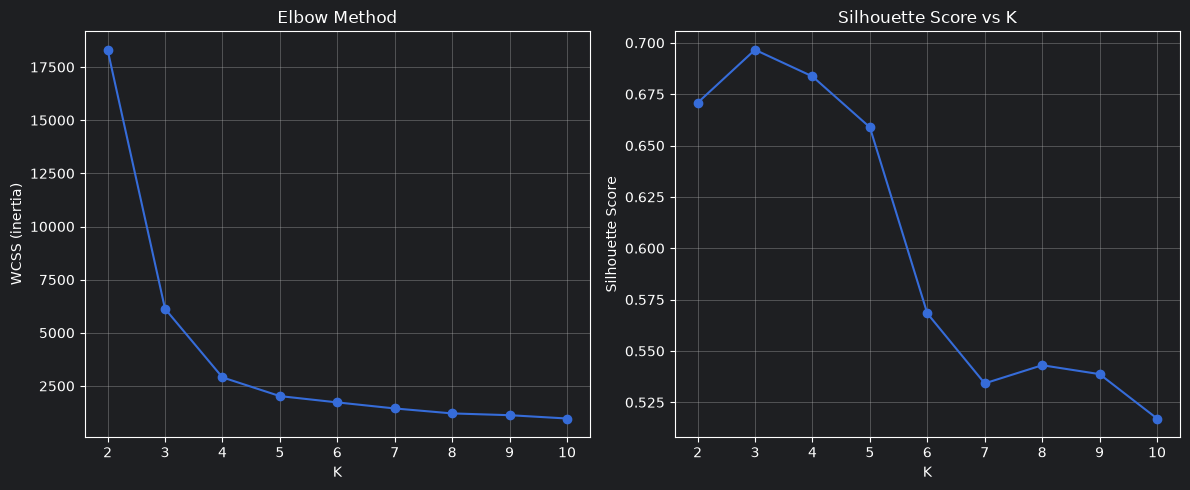

Best K by silhouette score: 3 (score=0.6966)


In [4]:
from kmeans_evaluator import KMeansEvaluator

evaluator = KMeansEvaluator(X)
evaluator.evaluate()

### K-Means Discussion

Comparing K = 2 through K = 5 visually, **K = 3 best matches the data's structure:** it cleanly isolates both the top right and bottom left while also revealing the middle cluster as a third visible region, whereas K = 2 hides that middle portion by splitting and absorbing it into the nearest blob.

K = 4 and K = 5 isolate the blobs too, but arbitrarily slice the middle part into two or three pieces despite no visible gap justifying a split — clear over-segmentation.

This matches the WCSS/silhouette evaluation (which was something I added as an extra thing), where K = 3 gives the highest silhouette score (0.6966) right where the elbow flattens out.

Still, separation isn't perfect at K = 3: the middle part's left tail blends into the bottom-left blob since it curves toward it with no clear gap, so K-means pulls those points into the nearer cluster.

Overall, K = 3 best balances the visual and quantitative evidence, avoiding both K = 2's under-segmentation and K = 4/K = 5's unjustified splitting.

*AI Declaration: I used AI to make the evaluation metric methods*

## DBSCAN experiments

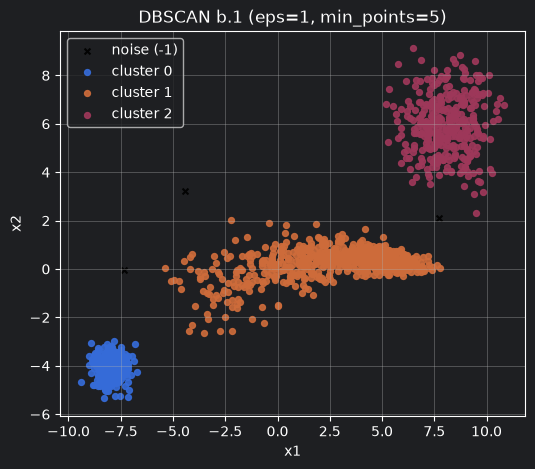

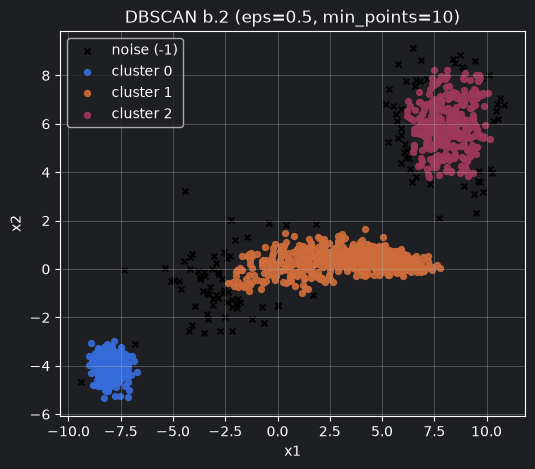

In [16]:
import numpy as np
from sklearn.cluster import DBSCAN

# Vary these
EPS = 1          # epsilon=neighbourhood radius
MIN_POINTS = 5     # min_samples = min_points

# Fit DBSCAN and get labels
labels = DBSCAN(eps=EPS, min_samples=MIN_POINTS).fit_predict(X)

#labels: -1 = noise; 0,1,2,... = cluster IDs

# Example usage:
plot_clustering_result(X, labels, title=f"DBSCAN b.1 (eps={EPS}, min_points={MIN_POINTS})")

# DUPLICATED TO SHOW FOR PART b.2

# Vary these
EPS = 0.5          # epsilon=neighbourhood radius
MIN_POINTS = 10     # min_samples = min_points

# Fit DBSCAN and get labels
labels = DBSCAN(eps=EPS, min_samples=MIN_POINTS).fit_predict(X)

#labels: -1 = noise; 0,1,2,... = cluster IDs

# Example usage:
plot_clustering_result(X, labels, title=f"DBSCAN b.2 (eps={EPS}, min_points={MIN_POINTS})")

### DBSCAN Evaluation

In [14]:
from dbscan_evaluator import DBSCANEvaluator

dbscan_evaluator = DBSCANEvaluator(X)
dbscan_evaluator.evaluate()
dbscan_evaluator.filter_by_clusters(3)

,eps,min_points,n_clusters,noise_frac,silhouette
0,1.0,3,3,0.002143,0.687553
1,1.0,5,3,0.002143,0.687553
2,1.5,3,3,0.002143,0.687553
3,1.5,5,3,0.002143,0.687553
4,1.5,8,3,0.002143,0.687553
5,1.5,10,3,0.002143,0.687553
6,1.0,8,3,0.005000,0.689403
7,1.0,10,3,0.007143,0.692015
8,0.7,8,3,0.020000,0.704045
9,0.7,10,3,0.027143,0.709717


### DBSCAN Discussion

#### Part 1.b.1
**EPS = 1, MIN_POINTS = 5 → 3 clusters (excluding noise), noise fraction ≈ 0.21%, silhouette ≈ 0.688.**

EPS = 1 is large enough to bridge the typical point-to-point spacing within each of the three dense regions, so nearly every point qualifies as a core point and gets absorbed into its cluster.

It is still smaller than the gaps between the three regions, so nothing gets merged across them by mistake. MIN_POINTS = 5 is low relative to how densely packed each region is, which is why almost no points fall below the density threshold and get flagged as noise.

The result is also stable rather than a lucky pick, since at EPS = 1 the same 3-cluster, near-zero-noise outcome holds for MIN_POINTS anywhere from 3 to 10.

#### Part 1.b.2

**EPS = 0.5, MIN_POINTS = 10 → 3 clusters (excluding noise), noise fraction ≈ 8.4%, silhouette ≈ 0.747.**

EPS = 0.5 is much smaller than the 1.0–1.5 range used in (b.1), so a point now only counts as a neighbour of another if it sits noticeably closer to it, which excludes the sparser, looser points at the edges of each region.

MIN_POINTS = 10 is also higher, so a point needs many close neighbours packed within that small radius to be treated as a core point, a condition only the tightest parts of each cluster satisfy.

Together these settings push the noise fraction up to 8.4% and the silhouette score to 0.747, higher than in (b.1), showing that what remains after pruning the sparser points is a smaller set of more tightly packed, better separated cores.

